# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [92]:
# %pip install --upgrade plotly

## Import Statements

In [172]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [94]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [95]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

In [96]:
US_states = {
    "AL": "Alabama",
    "AK": "Alaska",
    "AZ": "Arizona",
    "AR": "Arkansas",
    "CA": "California",
    "CO": "Colorado",
    "CT": "Connecticut",
    "DE": "Delaware",
    "FL": "Florida",
    "GA": "Georgia",
    "HI": "Hawaii",
    "ID": "Idaho",
    "IL": "Illinois",
    "IN": "Indiana",
    "IA": "Iowa",
    "KS": "Kansas",
    "KY": "Kentucky",
    "LA": "Louisiana",
    "ME": "Maine",
    "MD": "Maryland",
    "MA": "Massachusetts",
    "MI": "Michigan",
    "MN": "Minnesota",
    "MS": "Mississippi",
    "MO": "Missouri",
    "MT": "Montana",
    "NE": "Nebraska",
    "NV": "Nevada",
    "NH": "New Hampshire",
    "NJ": "New Jersey",
    "NM": "New Mexico",
    "NY": "New York",
    "NC": "North Carolina",
    "ND": "North Dakota",
    "OH": "Ohio",
    "OK": "Oklahoma",
    "OR": "Oregon",
    "PA": "Pennsylvania",
    "RI": "Rhode Island",
    "SC": "South Carolina",
    "SD": "South Dakota",
    "TN": "Tennessee",
    "TX": "Texas",
    "UT": "Utah",
    "VT": "Vermont",
    "VA": "Virginia",
    "WA": "Washington",
    "WV": "West Virginia",
    "WI": "Wisconsin",
    "WY": "Wyoming"
}

In [97]:
len(US_states)

50

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [98]:
df_hh_income.head()

,Geographic Area,City,Median Income
0,AL,Abanda CDP,11207
1,AL,Abbeville city,25615
2,AL,Adamsville city,42575
3,AL,Addison town,37083
4,AL,Akron town,21667


In [99]:
df_hh_income["State"] = df_hh_income["Geographic Area"].map(US_states)
df_hh_income.head()

,Geographic Area,City,Median Income,State
0,AL,Abanda CDP,11207,Alabama
1,AL,Abbeville city,25615,Alabama
2,AL,Adamsville city,42575,Alabama
3,AL,Addison town,37083,Alabama
4,AL,Akron town,21667,Alabama


In [100]:
df_hh_income.shape

(29322, 4)

In [101]:
df_hh_income.isnull().sum()

Geographic Area     0
City                0
Median Income      51
State               1
dtype: int64

In [102]:
df_hh_income.dropna(inplace=True)

In [103]:
df_hh_income.duplicated().sum()

np.int64(0)

In [104]:
df_pct_poverty.head()

,Geographic Area,City,poverty_rate
0,AL,Abanda CDP,78.8
1,AL,Abbeville city,29.1
2,AL,Adamsville city,25.5
3,AL,Addison town,30.7
4,AL,Akron town,42


In [105]:
df_pct_poverty["State"] = df_pct_poverty["Geographic Area"].map(US_states)
df_pct_poverty.head()

,Geographic Area,City,poverty_rate,State
0,AL,Abanda CDP,78.8,Alabama
1,AL,Abbeville city,29.1,Alabama
2,AL,Adamsville city,25.5,Alabama
3,AL,Addison town,30.7,Alabama
4,AL,Akron town,42,Alabama


In [106]:
df_pct_poverty.shape

(29329, 4)

In [107]:
df_pct_poverty.dtypes

Geographic Area    str
City               str
poverty_rate       str
State              str
dtype: object

In [108]:
df_pct_poverty[df_pct_poverty["poverty_rate"] == "-"]

,Geographic Area,City,poverty_rate,State
573,AL,Whatley CDP,-,Alabama
608,AK,Attu Station CDP,-,Alaska
632,AK,Chicken CDP,-,Alaska
637,AK,Chisana CDP,-,Alaska
662,AK,Dot Lake CDP,-,Alaska
...,...,...,...,...
29261,WY,Oakley CDP,-,Wyoming
29266,WY,Owl Creek CDP,-,Wyoming
29273,WY,Powder River CDP,-,Wyoming
29289,WY,Ryan Park CDP,-,Wyoming


In [109]:
df_pct_poverty.drop(df_pct_poverty[df_pct_poverty["poverty_rate"] == "-"].index, inplace=True)
df_pct_poverty["poverty_rate"] = df_pct_poverty["poverty_rate"].astype(float)
df_pct_poverty.head()

,Geographic Area,City,poverty_rate,State
0,AL,Abanda CDP,78.80,Alabama
1,AL,Abbeville city,29.10,Alabama
2,AL,Adamsville city,25.50,Alabama
3,AL,Addison town,30.70,Alabama
4,AL,Akron town,42.00,Alabama


In [110]:
df_pct_poverty.isnull().sum()

Geographic Area    0
City               0
poverty_rate       0
State              1
dtype: int64

In [111]:
df_pct_poverty.duplicated().sum()

np.int64(0)

In [112]:
df_pct_completed_hs.head()

,Geographic Area,City,percent_completed_hs
0,AL,Abanda CDP,21.2
1,AL,Abbeville city,69.1
2,AL,Adamsville city,78.9
3,AL,Addison town,81.4
4,AL,Akron town,68.6


In [113]:
df_pct_completed_hs["State"] = df_pct_completed_hs["Geographic Area"].map(US_states)
df_pct_completed_hs.head()

,Geographic Area,City,percent_completed_hs,State
0,AL,Abanda CDP,21.2,Alabama
1,AL,Abbeville city,69.1,Alabama
2,AL,Adamsville city,78.9,Alabama
3,AL,Addison town,81.4,Alabama
4,AL,Akron town,68.6,Alabama


In [114]:
df_pct_completed_hs.shape

(29329, 4)

In [115]:
df_pct_completed_hs.isnull().sum()

Geographic Area         0
City                    0
percent_completed_hs    0
State                   1
dtype: int64

In [116]:
df_pct_completed_hs.duplicated().sum()

np.int64(0)

In [134]:
df_pct_completed_hs.drop(df_pct_completed_hs[df_pct_completed_hs["percent_completed_hs"] == "-"].index, inplace=True)
df_pct_completed_hs["percent_completed_hs"] = df_pct_completed_hs["percent_completed_hs"].astype(float)
df_pct_completed_hs.head()

,Geographic Area,City,percent_completed_hs,State
0,AL,Abanda CDP,21.20,Alabama
1,AL,Abbeville city,69.10,Alabama
2,AL,Adamsville city,78.90,Alabama
3,AL,Addison town,81.40,Alabama
4,AL,Akron town,68.60,Alabama


In [117]:
df_share_race_city.head()

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic
0,AL,Abanda CDP,67.2,30.2,0,0,1.6
1,AL,Abbeville city,54.4,41.4,0.1,1,3.1
2,AL,Adamsville city,52.3,44.9,0.5,0.3,2.3
3,AL,Addison town,99.1,0.1,0,0.1,0.4
4,AL,Akron town,13.2,86.5,0,0,0.3


In [118]:
df_share_race_city.rename(columns={"Geographic area": "Geographic Area"}, inplace=True)
df_share_race_city["State"] = df_share_race_city["Geographic Area"].map(US_states)
df_share_race_city.head()

,Geographic Area,City,share_white,share_black,share_native_american,share_asian,share_hispanic,State
0,AL,Abanda CDP,67.2,30.2,0,0,1.6,Alabama
1,AL,Abbeville city,54.4,41.4,0.1,1,3.1,Alabama
2,AL,Adamsville city,52.3,44.9,0.5,0.3,2.3,Alabama
3,AL,Addison town,99.1,0.1,0,0.1,0.4,Alabama
4,AL,Akron town,13.2,86.5,0,0,0.3,Alabama


In [182]:
df_share_race_city.drop(df_share_race_city[df_share_race_city["share_white"] == "(X)"].index, inplace=True)
df_share_race_city.drop(df_share_race_city[df_share_race_city["share_black"] == "(X)"].index, inplace=True)
df_share_race_city.drop(df_share_race_city[df_share_race_city["share_hispanic"] == "(X)"].index, inplace=True)
df_share_race_city.drop(df_share_race_city[df_share_race_city["share_asian"] == "(X)"].index, inplace=True)
df_share_race_city.drop(df_share_race_city[df_share_race_city["share_native_american"] == "(X)"].index, inplace=True)

df_share_race_city["share_white"] = df_share_race_city["share_white"].astype(float)
df_share_race_city["share_black"] = df_share_race_city["share_black"].astype(float)
df_share_race_city["share_hispanic"] = df_share_race_city["share_hispanic"].astype(float)
df_share_race_city["share_asian"] = df_share_race_city["share_asian"].astype(float)
df_share_race_city["share_native_american"] = df_share_race_city["share_native_american"].astype(float)
df_share_race_city.head()

,Geographic Area,City,share_white,share_black,share_native_american,share_asian,share_hispanic,State
0,AL,Abanda CDP,67.20,30.20,0.00,0.00,1.60,Alabama
1,AL,Abbeville city,54.40,41.40,0.10,1.00,3.10,Alabama
2,AL,Adamsville city,52.30,44.90,0.50,0.30,2.30,Alabama
3,AL,Addison town,99.10,0.10,0.00,0.10,0.40,Alabama
4,AL,Akron town,13.20,86.50,0.00,0.00,0.30,Alabama


In [183]:
df_share_race_city.shape

(29248, 8)

In [120]:
df_share_race_city.isnull().sum()

Geographic Area          0
City                     0
share_white              0
share_black              0
share_native_american    0
share_asian              0
share_hispanic           0
State                    1
dtype: int64

In [121]:
df_share_race_city.duplicated().sum()

np.int64(0)

In [122]:
df_fatalities.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False


In [123]:
df_fatalities.rename(columns={"state": "Geographic Area"}, inplace=True)
df_fatalities["State"] = df_fatalities["Geographic Area"].map(US_states)
df_fatalities.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,Geographic Area,signs_of_mental_illness,threat_level,flee,body_camera,State
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False,Washington
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False,Oregon
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False,Kansas
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False,California
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False,Colorado


In [124]:
df_fatalities.shape

(2535, 15)

In [125]:
df_fatalities.isnull().sum()

id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
Geographic Area              0
signs_of_mental_illness      0
threat_level                 0
flee                        65
body_camera                  0
State                       11
dtype: int64

In [126]:
df_fatalities.dropna(inplace=True)

In [127]:
df_fatalities.duplicated().sum()

np.int64(0)

## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate. 

# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [128]:
df_pct_poverty.head()

,Geographic Area,City,poverty_rate,State
0,AL,Abanda CDP,78.80,Alabama
1,AL,Abbeville city,29.10,Alabama
2,AL,Adamsville city,25.50,Alabama
3,AL,Addison town,30.70,Alabama
4,AL,Akron town,42.00,Alabama


In [129]:
poverty_in_US = df_pct_poverty.groupby(["State", "Geographic Area"], as_index=False)["poverty_rate"].mean()
poverty_in_US.sort_values(by="poverty_rate", inplace=True)
poverty_in_US.head()

,State,Geographic Area,poverty_rate
29,New Jersey,NJ,8.19
6,Connecticut,CT,9.14
20,Massachusetts,MA,9.59
49,Wyoming,WY,9.89
19,Maryland,MD,10.31


In [130]:
fig = px.bar(poverty_in_US, x='State', y='poverty_rate')
fig.show()

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [131]:
df_pct_completed_hs.head()

,Geographic Area,City,percent_completed_hs,State
0,AL,Abanda CDP,21.2,Alabama
1,AL,Abbeville city,69.1,Alabama
2,AL,Adamsville city,78.9,Alabama
3,AL,Addison town,81.4,Alabama
4,AL,Akron town,68.6,Alabama


In [135]:
graduation_rate_US = df_pct_completed_hs.groupby(["State", "Geographic Area"], as_index=False)["percent_completed_hs"].mean()
graduation_rate_US.sort_values(by="percent_completed_hs", ascending=False, inplace=True)
graduation_rate_US.head()

,State,Geographic Area,percent_completed_hs
20,Massachusetts,MA,92.40
49,Wyoming,WY,92.10
10,Hawaii,HI,91.67
43,Utah,UT,91.62
6,Connecticut,CT,91.59


In [136]:
fig = px.bar(graduation_rate_US, x='State', y='percent_completed_hs')
fig.show()

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

In [161]:
poverty_and_graduation = pd.merge(poverty_in_US, graduation_rate_US, on=["State", "Geographic Area"])
poverty_and_graduation.sort_values(by="poverty_rate", inplace=True)
poverty_and_graduation.head()

,State,Geographic Area,poverty_rate,percent_completed_hs
0,New Jersey,NJ,8.19,90.85
1,Connecticut,CT,9.14,91.59
2,Massachusetts,MA,9.59,92.40
3,Wyoming,WY,9.89,92.10
4,Maryland,MD,10.31,88.42


In [ ]:
fig = go.Figure()

# First line (left y-axis)
fig.add_trace(
    go.Scatter(
        x=poverty_and_graduation["State"],
        y=poverty_and_graduation["poverty_rate"],
        name="Poverty Rate",
        mode="lines+markers",
        yaxis="y1"
    )
)

# Second line (right y-axis)
fig.add_trace(
    go.Scatter(
        x=poverty_and_graduation["State"],
        y=poverty_and_graduation["percent_completed_hs"],
        name="HS Completion %",
        mode="lines+markers",
        yaxis="y2"
    )
)

# Layout with two y-axes
fig.update_layout(
    xaxis=dict(title="State"),
    yaxis=dict(
        title="Poverty Rate (%)",
        side="left"
    ),
    yaxis2=dict(
        title="HS Completion (%)",
        overlaying="y",   # key part (like twinx)
        side="right"
    ),
    title="Poverty Rate vs High School Completion by State"
)

fig.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

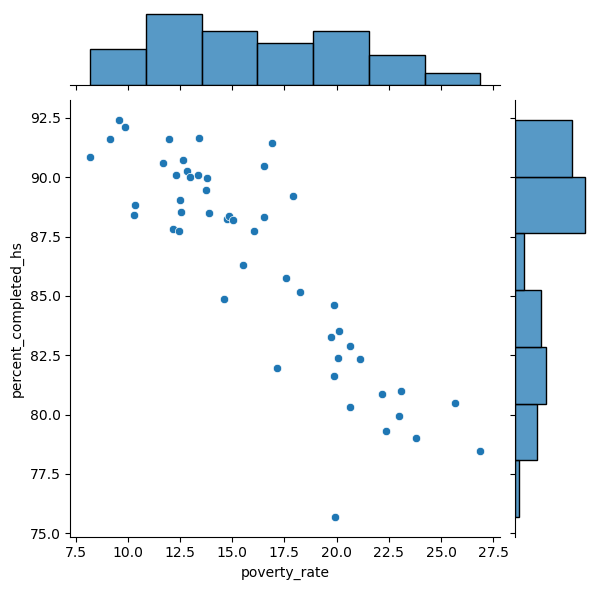

In [173]:
sns.jointplot(data=poverty_and_graduation, x="poverty_rate", y="percent_completed_hs")

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio. 

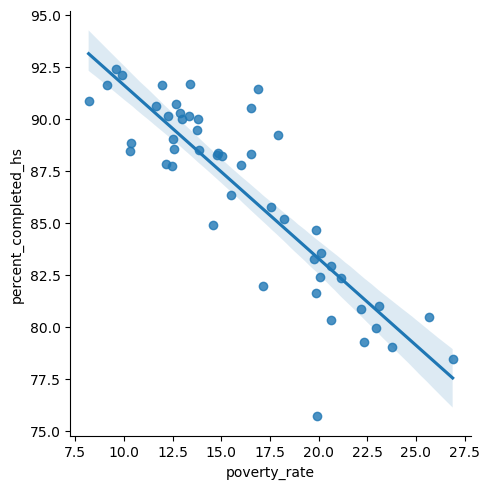

In [174]:
sns.lmplot(data=poverty_and_graduation, x="poverty_rate", y="percent_completed_hs")

<Axes: xlabel='poverty_rate', ylabel='percent_completed_hs'>

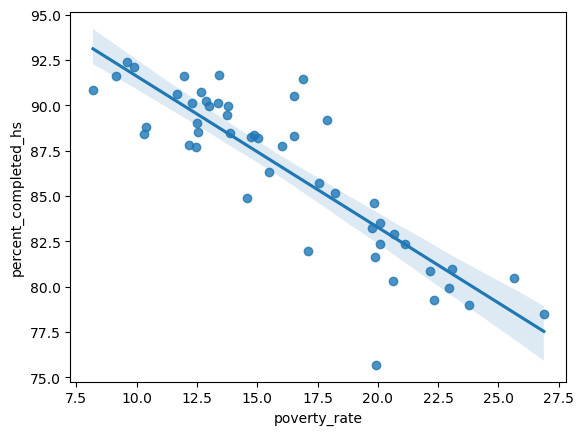

In [175]:
sns.regplot(data=poverty_and_graduation, x="poverty_rate", y="percent_completed_hs")

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections. 

In [176]:
df_share_race_city.head()

,Geographic Area,City,share_white,share_black,share_native_american,share_asian,share_hispanic,State
0,AL,Abanda CDP,67.2,30.2,0,0,1.6,Alabama
1,AL,Abbeville city,54.4,41.4,0.1,1,3.1,Alabama
2,AL,Adamsville city,52.3,44.9,0.5,0.3,2.3,Alabama
3,AL,Addison town,99.1,0.1,0,0.1,0.4,Alabama
4,AL,Akron town,13.2,86.5,0,0,0.3,Alabama


In [187]:
races_in_US = df_share_race_city.groupby(["State", "Geographic Area"], as_index=False).agg({"share_white": "mean", "share_black": "mean", "share_hispanic": "mean", "share_asian": "mean", "share_native_american": "mean"})
races_in_US.sort_values(by="share_white", ascending=False, inplace=True)
races_in_US.head()

,State,Geographic Area,share_white,share_black,share_hispanic,share_asian,share_native_american
14,Iowa,IA,96.71,0.56,2.82,0.40,0.27
44,Vermont,VT,95.87,0.77,1.38,0.91,0.37
18,Maine,ME,95.69,0.82,1.31,1.03,0.55
28,New Hampshire,NH,95.68,0.72,1.74,1.34,0.29
47,West Virginia,WV,95.04,2.92,0.90,0.34,0.20


In [188]:
fig = px.bar(races_in_US, x='State', y=['share_white', 'share_black', 'share_hispanic', 'share_asian', 'share_native_american'])
fig.show()

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

In [189]:
df_fatalities.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,Geographic Area,signs_of_mental_illness,threat_level,flee,body_camera,State
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False,Washington
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False,Oregon
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False,Kansas
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False,California
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False,Colorado


In [192]:
shot_by_race = df_fatalities["race"].value_counts()
shot_by_race

race
W    1167
B     582
H     401
A      36
N      29
O      28
Name: count, dtype: int64

In [ ]:
fig = px.pie(shot_by_race, values='count', names=shot_by_race.index)
fig.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women. 

In [193]:
shot_by_gender = df_fatalities["gender"].value_counts()
shot_by_gender

gender
M    2151
F      92
Name: count, dtype: int64

In [194]:
fig = px.pie(shot_by_gender, values='count', names=shot_by_gender.index)
fig.show()

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death? 

In [195]:
df_fatalities.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,Geographic Area,signs_of_mental_illness,threat_level,flee,body_camera,State
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False,Washington
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False,Oregon
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False,Kansas
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False,California
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False,Colorado


In [197]:
px.histogram(df_fatalities, x="age")

In [198]:
manner_of_death = df_fatalities["manner_of_death"].value_counts()
manner_of_death

manner_of_death
shot                2089
shot and Tasered     154
Name: count, dtype: int64

In [199]:
fig = px.pie(manner_of_death, values='count', names=manner_of_death.index)
fig.show()

# Were People Armed? 

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed? 

In [230]:
arms = (df_fatalities["armed"].value_counts() / df_fatalities["armed"].value_counts().sum()) * 100
arms.sort_values(inplace=True)
arms

armed
baseball bat and bottle    0.04
pipe                       0.04
beer bottle                0.04
pole and knife             0.04
air conditioner            0.04
                           ... 
toy weapon                 4.46
vehicle                    7.04
unarmed                    7.31
knife                     14.36
gun                       55.37
Name: count, Length: 66, dtype: float64

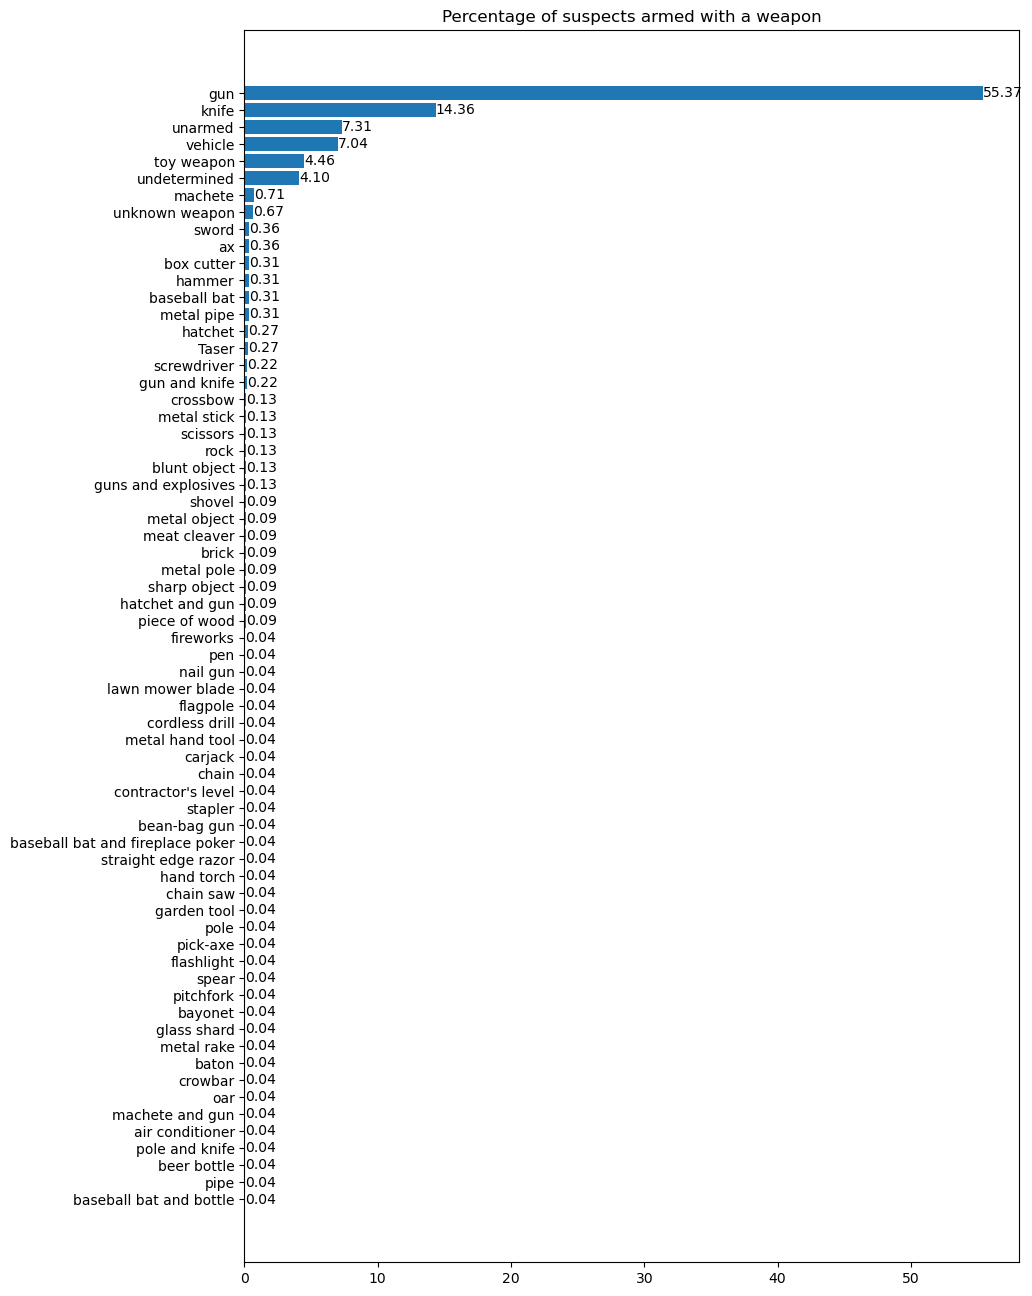

In [233]:
fig, ax = plt.subplots()
fig.set_figwidth(10)
fig.set_figheight(16)
hbars = ax.barh(arms.index, arms.values, align='center')
ax.set_yticks(arms.index, arms.index)
ax.set_title('Percentage of suspects armed with a weapon')

# Label with specially formatted floats
ax.bar_label(hbars, fmt='%.2f')

plt.show()


# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [235]:
(df_fatalities[df_fatalities["age"] < 25].shape[0] / df_fatalities.shape[0]) * 100

18.72492197949175

Create a histogram and KDE plot that shows the distribution of ages of the people killed by police. 

<Axes: xlabel='age', ylabel='Density'>

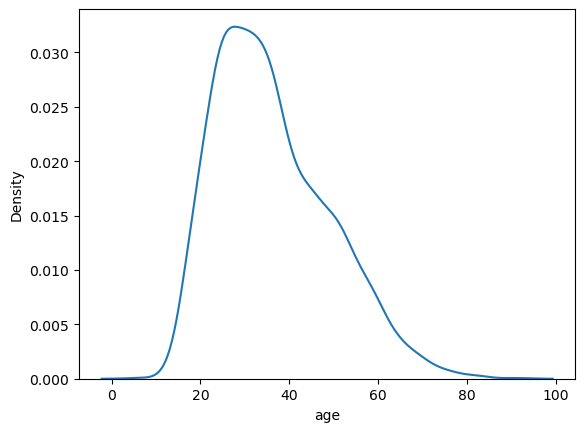

In [236]:
sns.kdeplot(data=df_fatalities, x="age")

Create a seperate KDE plot for each race. Is there a difference between the distributions? 

In [237]:
df_fatalities.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,Geographic Area,signs_of_mental_illness,threat_level,flee,body_camera,State
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False,Washington
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False,Oregon
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False,Kansas
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False,California
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False,Colorado


In [238]:
df_fatalities["race"].value_counts()

race
W    1167
B     582
H     401
A      36
N      29
O      28
Name: count, dtype: int64

In [ ]:
white = df_fatalities[df_fatalities["race"] == "W"]
black = df_fatalities[df_fatalities["race"] == "B"]
asian = df_fatalities[df_fatalities["race"] == "A"]
hispanic = df_fatalities[df_fatalities["race"] == "H"]
native_american = df_fatalities[df_fatalities["race"] == "N"]
other = df_fatalities[df_fatalities["race"] == "O"]

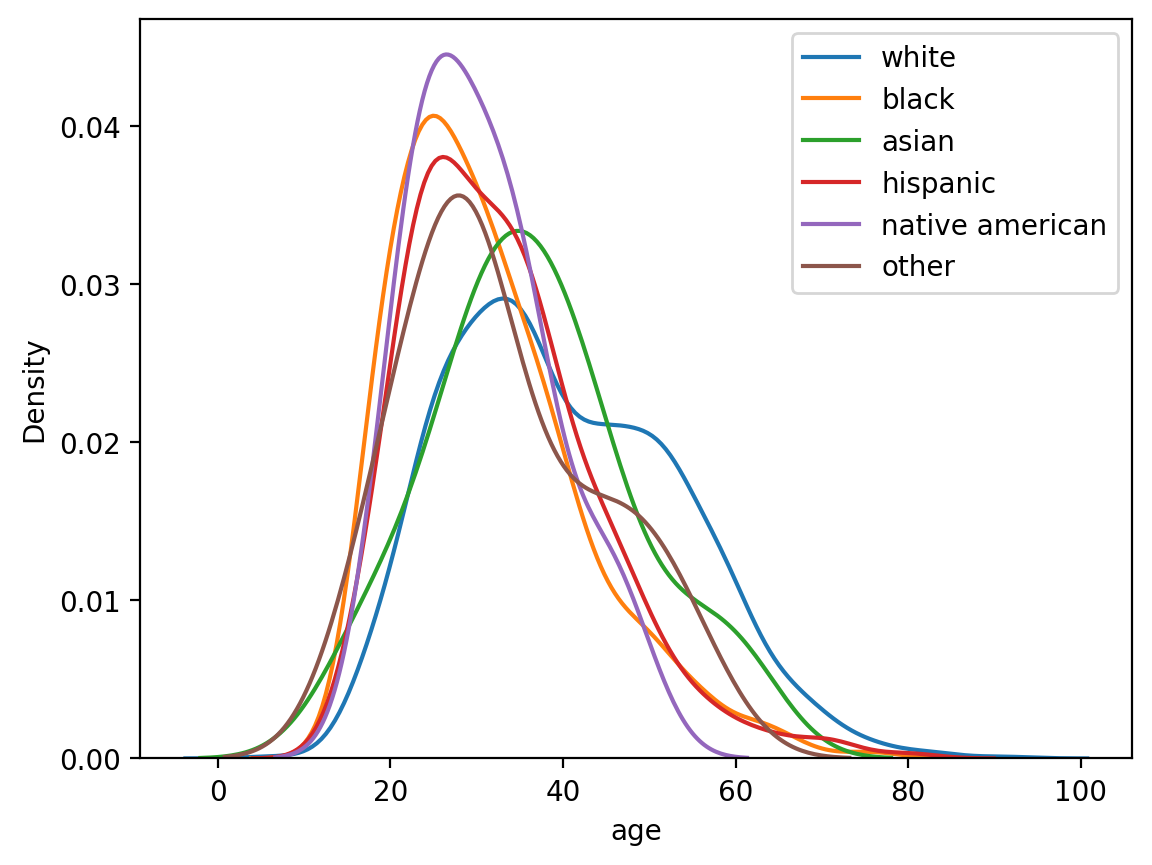

In [242]:
plt.figure(dpi=200)
sns.kdeplot(data=white, x="age", label="white")
sns.kdeplot(data=black, x="age", label="black")
sns.kdeplot(data=asian, x="age", label="asian")
sns.kdeplot(data=hispanic, x="age", label="hispanic")
sns.kdeplot(data=native_american, x="age", label="native american")
sns.kdeplot(data=other, x="age", label="other")
plt.legend()
plt.show()

# Race of People Killed

Create a chart that shows the total number of people killed by race. 

In [244]:
fig = px.pie(shot_by_race, values='count', names=shot_by_race.index)
fig.update_traces(textinfo='value')
fig.show()

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [246]:
mental_illness = df_fatalities["signs_of_mental_illness"].value_counts()
mental_illness

signs_of_mental_illness
False    1672
True      571
Name: count, dtype: int64

In [247]:
fig = px.pie(mental_illness, values='count', names=mental_illness.index)
fig.show()

# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

In [253]:
fatalities_by_city = df_fatalities["city"].value_counts()
fatalities_by_city.sort_values(ascending=False, inplace=True)
fatalities_by_city = fatalities_by_city.head(10)
fatalities_by_city

city
Los Angeles     35
Phoenix         28
Houston         24
Chicago         22
Austin          18
Las Vegas       17
Columbus        16
San Antonio     15
Miami           15
Indianapolis    14
Name: count, dtype: int64

In [255]:
px.bar(fatalities_by_city, x=fatalities_by_city.index, y=fatalities_by_city.values)

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city. 

In [324]:
race_columns = [
    "share_white",
    "share_black",
    "share_native_american",
    "share_asian",
    "share_hispanic"
]

In [325]:
Los_Angeles = df_share_race_city[df_share_race_city["City"] == "Los Angeles city"][df_share_race_city["State"] == "California"]
Los_Angeles

/tmp/ipykernel_3460156/3517157887.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Los_Angeles = df_share_race_city[df_share_race_city["City"] == "Los Angeles city"][df_share_race_city["State"] == "California"]


,Geographic Area,City,share_white,share_black,share_native_american,share_asian,share_hispanic,State
2714,CA,Los Angeles city,49.80,9.60,0.70,11.30,48.50,California


In [326]:
Los_Angeles = Los_Angeles[race_columns].iloc[0].reset_index()
Los_Angeles.columns = ["Race", "Share"]
Los_Angeles

,Race,Share
0,share_white,49.80
1,share_black,9.60
2,share_native_american,0.70
3,share_asian,11.30
4,share_hispanic,48.50


In [327]:
Phoenix = df_share_race_city[df_share_race_city["City"] == "Phoenix city"][df_share_race_city["State"] == "Arizona"]
Phoenix


/tmp/ipykernel_3460156/483543335.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Phoenix = df_share_race_city[df_share_race_city["City"] == "Phoenix city"][df_share_race_city["State"] == "Arizona"]


,Geographic Area,City,share_white,share_black,share_native_american,share_asian,share_hispanic,State
1201,AZ,Phoenix city,65.90,6.50,2.20,3.20,40.80,Arizona


In [328]:
Phoenix = Phoenix[race_columns].iloc[0].reset_index()
Phoenix.columns = ["Race", "Share"]
Phoenix

,Race,Share
0,share_white,65.90
1,share_black,6.50
2,share_native_american,2.20
3,share_asian,3.20
4,share_hispanic,40.80


In [329]:
Houston = df_share_race_city[df_share_race_city["City"] == "Houston city"][df_share_race_city["State"] == "Texas"]
Houston

/tmp/ipykernel_3460156/1069614918.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Houston = df_share_race_city[df_share_race_city["City"] == "Houston city"][df_share_race_city["State"] == "Texas"]


,Geographic Area,City,share_white,share_black,share_native_american,share_asian,share_hispanic,State
25157,TX,Houston city,50.50,23.70,0.70,6.00,43.80,Texas


In [330]:
Houston = Houston[race_columns].iloc[0].reset_index()
Houston.columns = ["Race", "Share"]
Houston

,Race,Share
0,share_white,50.50
1,share_black,23.70
2,share_native_american,0.70
3,share_asian,6.00
4,share_hispanic,43.80


In [334]:
Chicago = df_share_race_city[df_share_race_city["City"] == "Chicago city"][df_share_race_city["State"] == "Illinois"]
Chicago

/tmp/ipykernel_3460156/1089780692.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Chicago = df_share_race_city[df_share_race_city["City"] == "Chicago city"][df_share_race_city["State"] == "Illinois"]


,Geographic Area,City,share_white,share_black,share_native_american,share_asian,share_hispanic,State
6278,IL,Chicago city,45.00,32.90,0.50,5.50,28.90,Illinois


In [335]:
Chicago = Chicago[race_columns].iloc[0].reset_index()
Chicago.columns = ["Race", "Share"]
Chicago

,Race,Share
0,share_white,45.00
1,share_black,32.90
2,share_native_american,0.50
3,share_asian,5.50
4,share_hispanic,28.90


In [336]:
Austin = df_share_race_city[df_share_race_city["City"] == "Austin city"][df_share_race_city["State"] == "Texas"]
Austin

/tmp/ipykernel_3460156/4123452965.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Austin = df_share_race_city[df_share_race_city["City"] == "Austin city"][df_share_race_city["State"] == "Texas"]


,Geographic Area,City,share_white,share_black,share_native_american,share_asian,share_hispanic,State
24543,TX,Austin city,68.30,8.10,0.90,6.30,35.10,Texas


In [337]:
Austin = Austin[race_columns].iloc[0].reset_index()
Austin.columns = ["Race", "Share"]
Austin

,Race,Share
0,share_white,68.30
1,share_black,8.10
2,share_native_american,0.90
3,share_asian,6.30
4,share_hispanic,35.10


In [338]:
Las_Vegas = df_share_race_city[df_share_race_city["City"] == "Las Vegas city"][df_share_race_city["State"] == "Nevada"]
Las_Vegas

/tmp/ipykernel_3460156/682963487.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Las_Vegas = df_share_race_city[df_share_race_city["City"] == "Las Vegas city"][df_share_race_city["State"] == "Nevada"]


,Geographic Area,City,share_white,share_black,share_native_american,share_asian,share_hispanic,State
15666,NV,Las Vegas city,62.10,11.10,0.70,6.10,31.50,Nevada


In [339]:
Las_Vegas = Las_Vegas[race_columns].iloc[0].reset_index()
Las_Vegas.columns = ["Race", "Share"]
Las_Vegas

,Race,Share
0,share_white,62.10
1,share_black,11.10
2,share_native_american,0.70
3,share_asian,6.10
4,share_hispanic,31.50


In [340]:
Columbus = df_share_race_city[df_share_race_city["City"] == "Columbus city"][df_share_race_city["State"] == "Ohio"]
Columbus

/tmp/ipykernel_3460156/265959863.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Columbus = df_share_race_city[df_share_race_city["City"] == "Columbus city"][df_share_race_city["State"] == "Ohio"]


,Geographic Area,City,share_white,share_black,share_native_american,share_asian,share_hispanic,State
19379,OH,Columbus city,61.50,28.00,0.30,4.10,5.60,Ohio


In [341]:
Columbus = Columbus[race_columns].iloc[0].reset_index()
Columbus.columns = ["Race", "Share"]
Columbus

,Race,Share
0,share_white,61.50
1,share_black,28.00
2,share_native_american,0.30
3,share_asian,4.10
4,share_hispanic,5.60


In [342]:
San_Antonio = df_share_race_city[df_share_race_city["City"] == "San Antonio city"][df_share_race_city["State"] == "Texas"]
San_Antonio

/tmp/ipykernel_3460156/504861334.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  San_Antonio = df_share_race_city[df_share_race_city["City"] == "San Antonio city"][df_share_race_city["State"] == "Texas"]


,Geographic Area,City,share_white,share_black,share_native_american,share_asian,share_hispanic,State
25872,TX,San Antonio city,72.60,6.90,0.90,2.40,63.20,Texas


In [343]:
San_Antonio = San_Antonio[race_columns].iloc[0].reset_index()
San_Antonio.columns = ["Race", "Share"]
San_Antonio

,Race,Share
0,share_white,72.60
1,share_black,6.90
2,share_native_american,0.90
3,share_asian,2.40
4,share_hispanic,63.20


In [344]:
Miami = df_share_race_city[df_share_race_city["City"] == "Miami city"][df_share_race_city["State"] == "Florida"]
Miami

/tmp/ipykernel_3460156/455277704.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Miami = df_share_race_city[df_share_race_city["City"] == "Miami city"][df_share_race_city["State"] == "Florida"]


,Geographic Area,City,share_white,share_black,share_native_american,share_asian,share_hispanic,State
4633,FL,Miami city,72.60,19.20,0.30,1.00,70.00,Florida


In [345]:
Miami = Miami[race_columns].iloc[0].reset_index()
Miami.columns = ["Race", "Share"]
Miami

,Race,Share
0,share_white,72.60
1,share_black,19.20
2,share_native_american,0.30
3,share_asian,1.00
4,share_hispanic,70.00


In [346]:
Indianapolis = df_share_race_city[df_share_race_city["City"] == "Indianapolis city"][df_share_race_city["State"] == "Indiana"]
Indianapolis

/tmp/ipykernel_3460156/2512941313.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Indianapolis = df_share_race_city[df_share_race_city["City"] == "Indianapolis city"][df_share_race_city["State"] == "Indiana"]


,Geographic Area,City,share_white,share_black,share_native_american,share_asian,share_hispanic,State
7692,IN,Indianapolis city,62.00,27.30,0.30,2.10,9.40,Indiana


In [347]:
Indianapolis = Indianapolis[race_columns].iloc[0].reset_index()
Indianapolis.columns = ["Race", "Share"]
Indianapolis

,Race,Share
0,share_white,62.00
1,share_black,27.30
2,share_native_american,0.30
3,share_asian,2.10
4,share_hispanic,9.40


In [374]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create subplots: use 'domain' type for Pie subplot
fig = make_subplots(rows=2, cols=5, specs=[[{'type':'domain'}, {'type':'domain'}, {'type':'domain'}, {'type':'domain'}, {'type':'domain'}], [{'type':'domain'}, {'type':'domain'}, {'type':'domain'}, {'type':'domain'}, {'type':'domain'}]])

fig.add_trace(go.Pie(labels=Los_Angeles["Race"], values=Los_Angeles["Share"], name="Los Angeles"),
              1, 1)
fig.add_trace(go.Pie(labels=Phoenix["Race"], values=Phoenix["Share"], name="Phoenix"),
              1, 2)
fig.add_trace(go.Pie(labels=Houston["Race"], values=Houston["Share"], name="Houston"),
              1, 3)
fig.add_trace(go.Pie(labels=Chicago["Race"], values=Chicago["Share"], name="Chicago"),
              1, 4)
fig.add_trace(go.Pie(labels=Austin["Race"], values=Austin["Share"], name="Austin"),
              1, 5)
fig.add_trace(go.Pie(labels=Las_Vegas["Race"], values=Las_Vegas["Share"], name="Las Vegas"),
              2, 1)
fig.add_trace(go.Pie(labels=Columbus["Race"], values=Columbus["Share"], name="Columbus"),
              2, 2)
fig.add_trace(go.Pie(labels=San_Antonio["Race"], values=San_Antonio["Share"], name="San Antonio"),
              2, 3)
fig.add_trace(go.Pie(labels=Miami["Race"], values=Miami["Share"], name="Miami"),
              2, 4)
fig.add_trace(go.Pie(labels=Indianapolis["Race"], values=Indianapolis["Share"], name="Indianapolis"),
              2, 5)
              
              

# Use `hole` to create a donut-like pie chart
fig.update_traces(hole=.4, hoverinfo="label+percent+name")

fig.update_layout(
    title_text="Race structure in top 10 cities",
    # Add annotations in the center of the donut pies.
    annotations=[dict(text='Los Angeles', x=sum(fig.get_subplot(1, 1).x) / 2, y=0.47,
                      font_size=20, showarrow=False, xanchor="center"),
                 dict(text='Phoenix', x=sum(fig.get_subplot(1, 2).x) / 2, y=0.47,
                      font_size=20, showarrow=False, xanchor="center"),
                 dict(text='Houston', x=sum(fig.get_subplot(1, 3).x) / 2, y=0.47,
                      font_size=20, showarrow=False, xanchor="center"),
                 dict(text='Chicago', x=sum(fig.get_subplot(1, 4).x) / 2, y=0.47,
                      font_size=20, showarrow=False, xanchor="center"),
                 dict(text='Austin', x=sum(fig.get_subplot(1, 5).x) / 2, y=0.47,
                      font_size=20, showarrow=False, xanchor="center"),
                 dict(text='Las Vegas', x=sum(fig.get_subplot(2, 1).x) / 2, y=-0.17,
                      font_size=20, showarrow=False, xanchor="center"),
                 dict(text='Columbus', x=sum(fig.get_subplot(2, 2).x) / 2, y=-0.15,
                      font_size=20, showarrow=False, xanchor="center"),
                 dict(text='San Antonio', x=sum(fig.get_subplot(2, 3).x) / 2, y=-0.27,
                      font_size=20, showarrow=False, xanchor="center"),
                 dict(text='Miami', x=sum(fig.get_subplot(2, 4).x) / 2, y=-0.2,
                      font_size=20, showarrow=False, xanchor="center"),
                 dict(text='Indianapolis', x=sum(fig.get_subplot(2, 5).x) / 2, y=-0.15,
                      font_size=20, showarrow=False, xanchor="center"),
                      
                      ])
fig.show()

# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty? 

In [375]:
df_fatalities.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,Geographic Area,signs_of_mental_illness,threat_level,flee,body_camera,State
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False,Washington
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False,Oregon
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False,Kansas
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False,California
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False,Colorado


In [384]:
fatalities_by_state = df_fatalities.groupby(["State", "Geographic Area"], as_index=False)["name"].count()
fatalities_by_state.rename(columns={"name": "Fatalities"}, inplace=True)
fatalities_by_state.sort_values(by="Fatalities", ascending=False, inplace=True)
fatalities_by_state.head()

,State,Geographic Area,Fatalities
4,California,CA,366
42,Texas,TX,200
8,Florida,FL,136
2,Arizona,AZ,105
34,Ohio,OH,70


In [395]:
fig = px.choropleth(fatalities_by_state, locations="Geographic Area",
                    color="Fatalities",
                    hover_name="State",
                    scope="usa",
                    locationmode="USA-states",
                    color_continuous_scale=px.colors.sequential.matter)
fig.show()

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data? 

In [405]:
df_fatalities.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,Geographic Area,signs_of_mental_illness,threat_level,flee,body_camera,State
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False,Washington
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False,Oregon
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False,Kansas
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False,California
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False,Colorado


In [408]:
df_fatalities["datetime"] = pd.to_datetime(df_fatalities["date"])
df_fatalities.head()

/tmp/ipykernel_3460156/270448176.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_fatalities["datetime"] = pd.to_datetime(df_fatalities["date"])


,id,name,date,manner_of_death,armed,age,gender,race,city,Geographic Area,signs_of_mental_illness,threat_level,flee,body_camera,State,datetime
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False,Washington,2015-02-01
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False,Oregon,2015-02-01
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False,Kansas,2015-03-01
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False,California,2015-04-01
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False,Colorado,2015-04-01


In [426]:
df_fatalities["month"] = df_fatalities["datetime"].dt.to_period("M").astype(str)
df_fatalities.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,Geographic Area,signs_of_mental_illness,threat_level,flee,body_camera,State,datetime,month
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False,Washington,2015-02-01,2015-02
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False,Oregon,2015-02-01,2015-02
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False,Kansas,2015-03-01,2015-03
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False,California,2015-04-01,2015-04
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False,Colorado,2015-04-01,2015-04


In [428]:
monthly_fatalities = df_fatalities.groupby(["month"], as_index=False)["name"].count()
monthly_fatalities.rename(columns={"name": "fatalities"}, inplace=True)
monthly_fatalities.head()

,month,fatalities
0,2015-01,68
1,2015-02,75
2,2015-03,86
3,2015-04,87
4,2015-05,84


In [432]:
fig = px.line(monthly_fatalities, x="month", y="fatalities")
fig.update_xaxes(tickvals=monthly_fatalities["month"].unique(), tickangle=90)
fig.show()

# Epilogue

Now that you have analysed the data yourself, read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).